In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [36]:
df = pd.read_csv("/content/Day16_Student_Wellbeing_Survey.csv")
print(df.shape)
df.head()

(600, 20)


,Student_ID,Age,Faculty,Year_of_Study,City,Accommodation,Scholarship,Part_Time_Job,Internet_Quality,Preferred_Study_Space,Weekly_Study_Hours,Average_Sleep_Hours,Daily_Screen_Time_Hours,Exercise_Days_Per_Week,Commute_Time_Minutes,Stress_Score,Academic_Readiness_Score,Overall_Satisfaction,Monthly_Discretionary_Spending,Social_Activity_Hours_Per_Week
0,STU0001,21,Data Science,3,Bengaluru,Hostel,No,Yes,Good,Café,15.2,5.7,3.2,3,11.8,5.4,63.1,3.2,5131.0,7.8
1,STU0002,21,Data Science,4,Pune,Hostel,Yes,No,Poor,Library,17.6,7.7,3.5,4,20.3,2.1,74.2,3.8,3508.0,9.2
2,STU0003,22,Life Sciences,2,Chandigarh,Home,Yes,No,Poor,Home,18.9,6.4,2.8,1,15.0,5.2,77.3,4.0,4584.0,7.7
3,STU0004,18,Business,4,Bengaluru,Hostel,Yes,Yes,Average,Café,19.5,6.7,3.0,5,12.1,4.7,67.0,4.0,5456.0,5.3
4,STU0005,20,Business,3,Jammu,Shared Apartment,Yes,No,Good,Home,18.4,7.3,3.0,1,30.2,5.4,65.6,3.2,11732.0,15.9


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Student_ID                      600 non-null    object 
 1   Age                             600 non-null    int64  
 2   Faculty                         600 non-null    object 
 3   Year_of_Study                   600 non-null    int64  
 4   City                            600 non-null    object 
 5   Accommodation                   600 non-null    object 
 6   Scholarship                     600 non-null    object 
 7   Part_Time_Job                   600 non-null    object 
 8   Internet_Quality                600 non-null    object 
 9   Preferred_Study_Space           600 non-null    object 
 10  Weekly_Study_Hours              600 non-null    float64
 11  Average_Sleep_Hours             600 non-null    float64
 12  Daily_Screen_Time_Hours         600 

In [38]:
print("no of duplicated rows : ",df.duplicated().sum())
df.isna().sum()


no of duplicated rows :  0


,0
Student_ID,0
Age,0
Faculty,0
Year_of_Study,0
City,0
Accommodation,0
Scholarship,0
Part_Time_Job,0
Internet_Quality,0
Preferred_Study_Space,0


In [39]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,600.0,20.763333,1.705531,17.0,20.000,21.00,22.000,25.0
Year_of_Study,600.0,2.388333,1.089116,1.0,1.000,2.00,3.000,4.0
Weekly_Study_Hours,600.0,15.691000,4.383725,4.0,13.000,15.40,18.425,34.0
Average_Sleep_Hours,600.0,6.997500,0.838679,4.5,6.475,7.00,7.600,9.5
Daily_Screen_Time_Hours,600.0,4.503000,1.862527,1.2,3.200,4.20,5.400,12.4
Exercise_Days_Per_Week,600.0,3.081667,1.909032,0.0,2.000,3.00,4.000,7.0
Commute_Time_Minutes,600.0,22.893833,12.774967,3.0,13.375,20.45,31.525,118.0
Stress_Score,600.0,4.464500,1.668081,1.0,3.300,4.50,5.700,9.4
Academic_Readiness_Score,600.0,71.773167,9.694430,41.9,65.200,71.65,78.025,98.0
Overall_Satisfaction,600.0,4.100167,0.502498,2.8,3.700,4.10,4.500,5.0


In [40]:
for col in ["Faculty", "Year_of_Study", "Accommodation", "Scholarship",
            "Part_Time_Job", "Internet_Quality", "Exercise_Days_Per_Week"]:
    print(f"--- {col} ---")
    print(df[col].value_counts().sort_index().to_string())
    print()

--- Faculty ---
Faculty
Arts & Humanities    123
Business             112
Data Science         128
Engineering          134
Life Sciences        103

--- Year_of_Study ---
Year_of_Study
1    164
2    159
3    157
4    120

--- Accommodation ---
Accommodation
Home                219
Hostel              175
PG                   95
Shared Apartment    111

--- Scholarship ---
Scholarship
No     416
Yes    184

--- Part_Time_Job ---
Part_Time_Job
No     448
Yes    152

--- Internet_Quality ---
Internet_Quality
Average      159
Excellent    109
Good         296
Poor          36

--- Exercise_Days_Per_Week ---
Exercise_Days_Per_Week
0     50
1     90
2    104
3    125
4     88
5     68
6     41
7     34



In [41]:
asked = ["Weekly_Study_Hours", "Average_Sleep_Hours", "Daily_Screen_Time_Hours",
        "Stress_Score", "Academic_Readiness_Score"]

def raw_mode(s):
    m = s.mode()
    return float(m.iloc[0]), len(m), int((s == m.iloc[0]).sum())

def modal_class(s, bins=12):
    counts, edges = np.histogram(s.dropna(), bins=bins)
    i = int(np.argmax(counts))
    return f"[{edges[i]:.1f}, {edges[i+1]:.1f})", (edges[i] + edges[i+1]) / 2, int(counts[i])

rows = []
for v in asked:
    s = df[v]
    mode_val, n_modes, mode_freq = raw_mode(s)
    cls, mid, freq = modal_class(s)
    rows.append({
        "Variable": v,
        "n": s.notna().sum(),
        "Mean": s.mean(),
        "Median": s.median(),
        "Mode (raw)": mode_val,
        "Mode freq": mode_freq,
        "#modes": n_modes,
        "Modal class": cls,
        "Modal midpoint": mid,
        "Class freq": freq,
    })

central = pd.DataFrame(rows).set_index("Variable")
central

,n,Mean,Median,Mode (raw),Mode freq,#modes,Modal class,Modal midpoint,Class freq
Variable,,,,,,,,,
Weekly_Study_Hours,600,15.691000,15.40,13.1,10,4,"[14.0, 16.5)",15.250000,140
Average_Sleep_Hours,600,6.997500,7.00,7.0,37,1,"[7.0, 7.4)",7.208333,142
Daily_Screen_Time_Hours,600,4.503000,4.20,3.5,20,1,"[3.1, 4.0)",3.533333,143
Stress_Score,600,4.464500,4.50,4.7,20,2,"[4.5, 5.2)",4.850000,101
Academic_Readiness_Score,600,71.773167,71.65,71.1,7,3,"[69.9, 74.6)",72.287500,125


In [42]:
# Mean vs median gap -> a simple, readable skewness signal
skew_tbl = pd.DataFrame({
    "Mean": df[asked].mean(),
    "Median": df[asked].median(),
})
skew_tbl["Mean - Median"] = skew_tbl["Mean"] - skew_tbl["Median"]
skew_tbl["Pearson skewness"] = df[asked].skew()
skew_tbl["Shape"] = np.where(skew_tbl["Mean - Median"].abs() < 0.05 * df[asked].std().values,
                             "≈ symmetric",
                             np.where(skew_tbl["Mean - Median"] > 0, "right-skewed", "left-skewed"))
skew_tbl

,Mean,Median,Mean - Median,Pearson skewness,Shape
Weekly_Study_Hours,15.691000,15.40,0.291000,0.157317,right-skewed
Average_Sleep_Hours,6.997500,7.00,-0.002500,-0.011242,≈ symmetric
Daily_Screen_Time_Hours,4.503000,4.20,0.303000,1.292580,right-skewed
Stress_Score,4.464500,4.50,-0.035500,0.111062,≈ symmetric
Academic_Readiness_Score,71.773167,71.65,0.123167,-0.129478,≈ symmetric


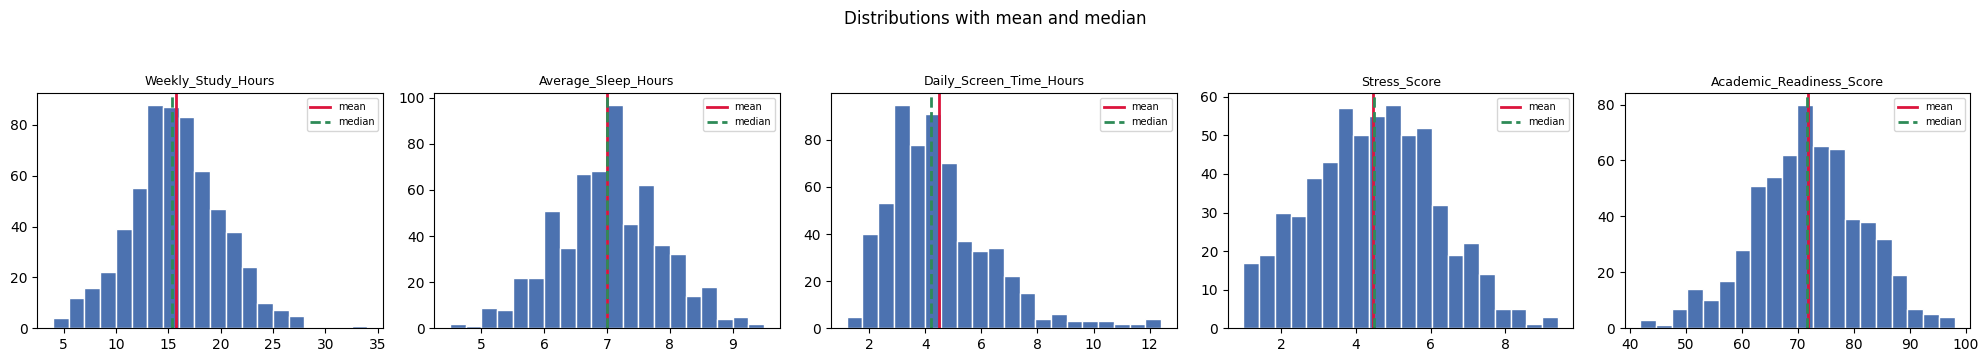

In [43]:
fig, axes = plt.subplots(1, 5, figsize=(20, 3.4))
for ax, v in zip(axes, asked):
    ax.hist(df[v], bins=20, color="#4C72B0", edgecolor="white")
    ax.axvline(df[v].mean(),   color="crimson",   lw=2, label="mean")
    ax.axvline(df[v].median(), color="seagreen",  lw=2, ls="--", label="median")
    ax.set_title(v, fontsize=9)
    ax.legend(fontsize=7)
plt.suptitle("Distributions with mean and median", y=1.05)
plt.tight_layout()
plt.show()

In [44]:
disp = pd.DataFrame(index=asked)
disp["Min"]      = df[asked].min()
disp["Max"]      = df[asked].max()
disp["Range"]    = df[asked].max() - df[asked].min()
disp["Variance"] = df[asked].var(ddof=1)
disp["Std Dev"]  = df[asked].std(ddof=1)
disp["Q1"]       = df[asked].quantile(0.25)
disp["Q3"]       = df[asked].quantile(0.75)
disp["IQR"]      = disp["Q3"] - disp["Q1"]
disp["Mean"]     = df[asked].mean()
disp["CV %"]     = disp["Std Dev"] / disp["Mean"] * 100
disp

,Min,Max,Range,Variance,Std Dev,Q1,Q3,IQR,Mean,CV %
Weekly_Study_Hours,4.0,34.0,30.0,19.217047,4.383725,13.000,18.425,5.425,15.691000,27.937832
Average_Sleep_Hours,4.5,9.5,5.0,0.703383,0.838679,6.475,7.600,1.125,6.997500,11.985411
Daily_Screen_Time_Hours,1.2,12.4,11.2,3.469006,1.862527,3.200,5.400,2.200,4.503000,41.361909
Stress_Score,1.0,9.4,8.4,2.782494,1.668081,3.300,5.700,2.400,4.464500,37.363219
Academic_Readiness_Score,41.9,98.0,56.1,93.981967,9.694430,65.200,78.025,12.825,71.773167,13.507039


In [45]:
abs_winner = disp["Std Dev"].idxmax()
cv_winner  = disp["CV %"].idxmax()
cv_loser   = disp["CV %"].idxmin()

print("GREATEST VARIABILITY")
print(f"  Absolute (largest std dev) : {abs_winner:<28} s = {disp.loc[abs_winner,'Std Dev']:.4f}")
print(f"  Relative (largest CV%)     : {cv_winner:<28} CV = {disp.loc[cv_winner,'CV %']:.2f}%")
print(f"  Most consistent (lowest CV): {cv_loser:<28} CV = {disp.loc[cv_loser,'CV %']:.2f}%")
print()
print(disp[["Std Dev", "IQR", "CV %"]].sort_values("CV %", ascending=False))

GREATEST VARIABILITY
  Absolute (largest std dev) : Academic_Readiness_Score     s = 9.6944
  Relative (largest CV%)     : Daily_Screen_Time_Hours      CV = 41.36%
  Most consistent (lowest CV): Average_Sleep_Hours          CV = 11.99%

                           Std Dev     IQR       CV %
Daily_Screen_Time_Hours   1.862527   2.200  41.361909
Stress_Score              1.668081   2.400  37.363219
Weekly_Study_Hours        4.383725   5.425  27.937832
Academic_Readiness_Score  9.694430  12.825  13.507039
Average_Sleep_Hours       0.838679   1.125  11.985411


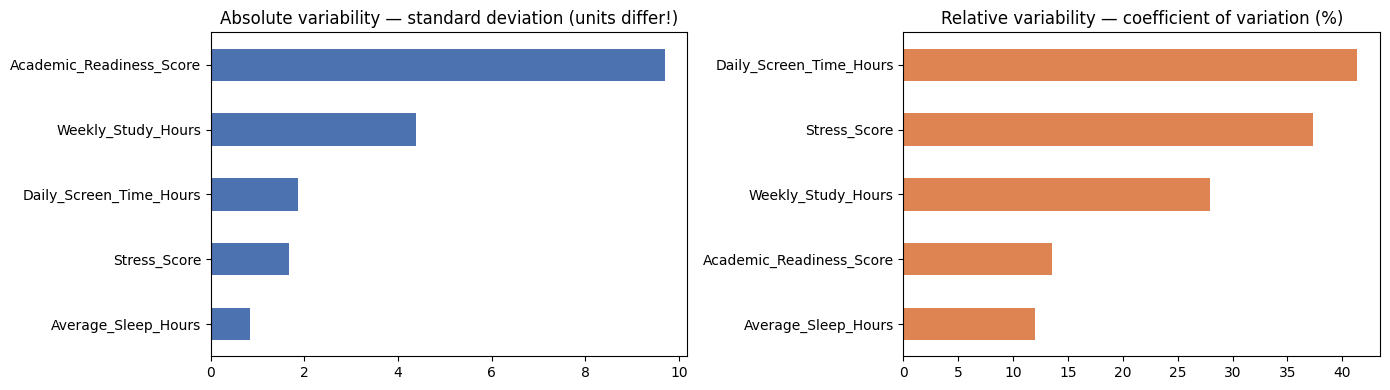

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
disp["Std Dev"].sort_values().plot.barh(ax=axes[0], color="#4C72B0")
axes[0].set_title("Absolute variability — standard deviation (units differ!)")
disp["CV %"].sort_values().plot.barh(ax=axes[1], color="#DD8452")
axes[1].set_title("Relative variability — coefficient of variation (%)")
plt.tight_layout()
plt.show()

In [47]:
OUT_asked = ["Weekly_Study_Hours", "Daily_Screen_Time_Hours",
            "Commute_Time_Minutes", "Monthly_Discretionary_Spending"]

def iqr_bounds(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1, q3, iqr, q1 - 1.5 * iqr, q3 + 1.5 * iqr

summary, masks = [], {}
for v in OUT_asked:
    s = df[v]
    q1, q3, iqr, lo, hi = iqr_bounds(s)
    mask = (s < lo) | (s > hi)
    masks[v] = mask
    summary.append({
        "Variable": v, "Q1": q1, "Q3": q3, "IQR": iqr,
        "Lower fence": lo, "Upper fence": hi,
        "Low outliers": int((s < lo).sum()),
        "High outliers": int((s > hi).sum()),
        "Total outliers": int(mask.sum()),
        "% of data": mask.mean() * 100,
    })

outlier_summary = pd.DataFrame(summary).set_index("Variable")
outlier_summary

,Q1,Q3,IQR,Lower fence,Upper fence,Low outliers,High outliers,Total outliers,% of data
Variable,,,,,,,,,
Weekly_Study_Hours,13.000,18.425,5.425,4.8625,26.5625,2,6,8,1.333333
Daily_Screen_Time_Hours,3.200,5.400,2.200,-0.1000,8.7000,0,18,18,3.000000
Commute_Time_Minutes,13.375,31.525,18.150,-13.8500,58.7500,0,4,4,0.666667
Monthly_Discretionary_Spending,4113.000,7808.500,3695.500,-1430.2500,13351.7500,0,20,20,3.333333


In [48]:
for v in OUT_asked:
    vals = np.sort(df.loc[masks[v], v].values)
    print(f"{v}  ->  {len(vals)} outlier(s)")
    print("   values:", np.round(vals, 2).tolist() if len(vals) else "none")
    print()

Weekly_Study_Hours  ->  8 outlier(s)
   values: [4.0, 4.3, 26.6, 26.6, 27.2, 27.2, 27.8, 34.0]

Daily_Screen_Time_Hours  ->  18 outlier(s)
   values: [9.0, 9.1, 9.2, 9.3, 9.8, 9.9, 10.1, 10.4, 10.4, 10.6, 11.0, 11.1, 11.3, 11.8, 12.0, 12.0, 12.0, 12.4]

Commute_Time_Minutes  ->  4 outlier(s)
   values: [62.3, 65.2, 72.5, 118.0]

Monthly_Discretionary_Spending  ->  20 outlier(s)
   values: [13697.0, 13875.0, 13945.0, 13946.0, 14064.0, 14097.0, 14522.0, 14594.0, 14667.0, 14698.0, 14718.0, 14809.0, 14859.0, 16791.0, 17349.0, 18038.0, 19559.0, 23782.0, 28000.0, 31500.0]



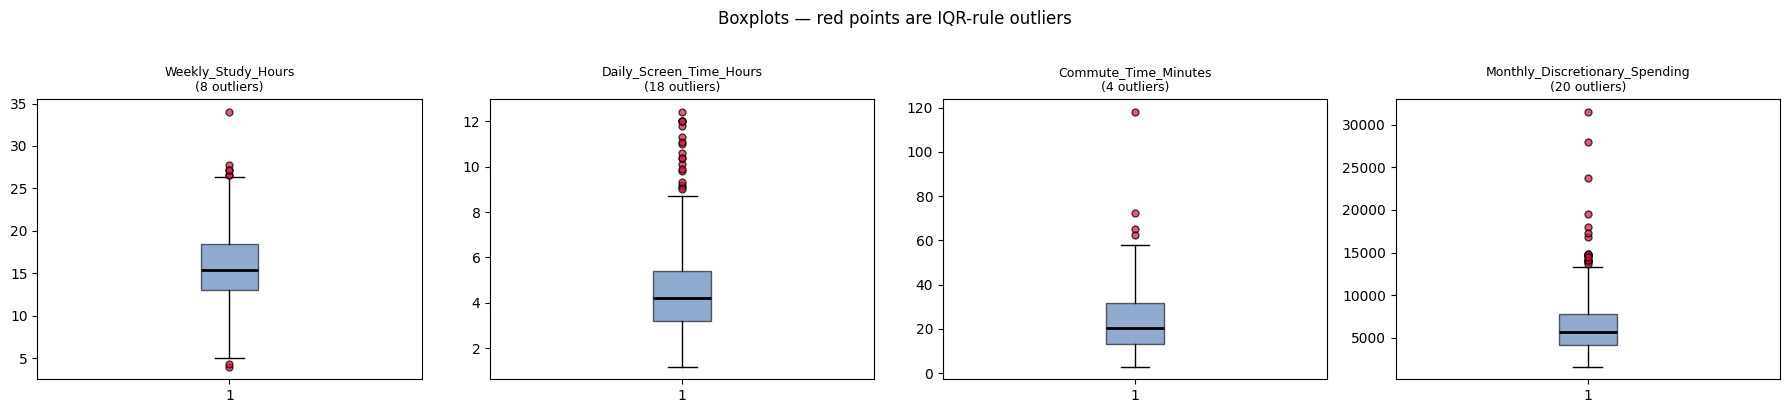

In [49]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, v in zip(axes, OUT_asked):
    ax.boxplot(df[v], vert=True, patch_artist=True,
               boxprops=dict(facecolor="#4C72B0", alpha=0.6),
               medianprops=dict(color="black", lw=2),
               flierprops=dict(marker="o", markerfacecolor="crimson",
                               markersize=5, alpha=0.7))
    ax.set_title(f"{v}\n({int(masks[v].sum())} outliers)", fontsize=9)
plt.suptitle("Boxplots — red points are IQR-rule outliers", y=1.02)
plt.tight_layout()
plt.show()

In [50]:
cmp_rows = []
for v in OUT_asked:
    before = df[v]
    after  = df.loc[~masks[v], v]
    cmp_rows.append({
        "Variable": v,
        "n before": before.size, "n after": after.size, "Removed": int(masks[v].sum()),
        "Mean before": before.mean(), "Mean after": after.mean(),
        "Mean Δ%": (after.mean() - before.mean()) / before.mean() * 100,
        "Median before": before.median(), "Median after": after.median(),
        "Median Δ%": (after.median() - before.median()) / before.median() * 100,
        "SD before": before.std(ddof=1), "SD after": after.std(ddof=1),
        "SD Δ%": (after.std(ddof=1) - before.std(ddof=1)) / before.std(ddof=1) * 100,
    })

comparison = pd.DataFrame(cmp_rows).set_index("Variable")
comparison[["Removed", "Mean before", "Mean after", "Mean Δ%",
            "Median before", "Median after", "Median Δ%", "SD before", "SD after", "SD Δ%"]]

,Removed,Mean before,Mean after,Mean Δ%,Median before,Median after,Median Δ%,SD before,SD after,SD Δ%
Variable,,,,,,,,,,
Weekly_Study_Hours,8,15.691000,15.602872,-0.561649,15.40,15.35,-0.324675,4.383725,4.165608,-4.975607
Daily_Screen_Time_Hours,18,4.503000,4.313402,-4.210481,4.20,4.10,-2.380952,1.862527,1.529512,-17.879731
Commute_Time_Minutes,4,22.893833,22.513926,-1.659430,20.45,20.35,-0.488998,12.774967,11.798165,-7.646219
Monthly_Discretionary_Spending,20,6343.778333,5973.718966,-5.833422,5685.50,5590.50,-1.670917,3290.470593,2501.846382,-23.966913


In [51]:
FOCUS = "Monthly_Discretionary_Spending"
before, after = df[FOCUS], df.loc[~masks[FOCUS], FOCUS]

print(f"FOCUS VARIABLE: {FOCUS}")
print("-" * 62)
print(f"{'':16}{'BEFORE':>14}{'AFTER':>14}{'CHANGE':>16}")
for label, f in [("Mean", np.mean), ("Median", np.median),
                 ("Std Dev", lambda x: np.std(x, ddof=1))]:
    b, a = f(before), f(after)
    print(f"{label:16}{b:>14,.2f}{a:>14,.2f}{a-b:>+14,.2f} ({(a-b)/b*100:+.2f}%)")
print(f"\n{'Observations':16}{before.size:>14,}{after.size:>14,}{after.size-before.size:>+14,}")
print(f"\nMean shifted {abs((after.mean()-before.mean())/before.mean()*100):.2f}% "
      f"but the median only moved "
      f"{abs((after.median()-before.median())/before.median()*100):.2f}%.")

FOCUS VARIABLE: Monthly_Discretionary_Spending
--------------------------------------------------------------
                        BEFORE         AFTER          CHANGE
Mean                  6,343.78      5,973.72       -370.06 (-5.83%)
Median                5,685.50      5,590.50        -95.00 (-1.67%)
Std Dev               3,290.47      2,501.85       -788.62 (-23.97%)

Observations               600           580           -20

Mean shifted 5.83% but the median only moved 1.67%.


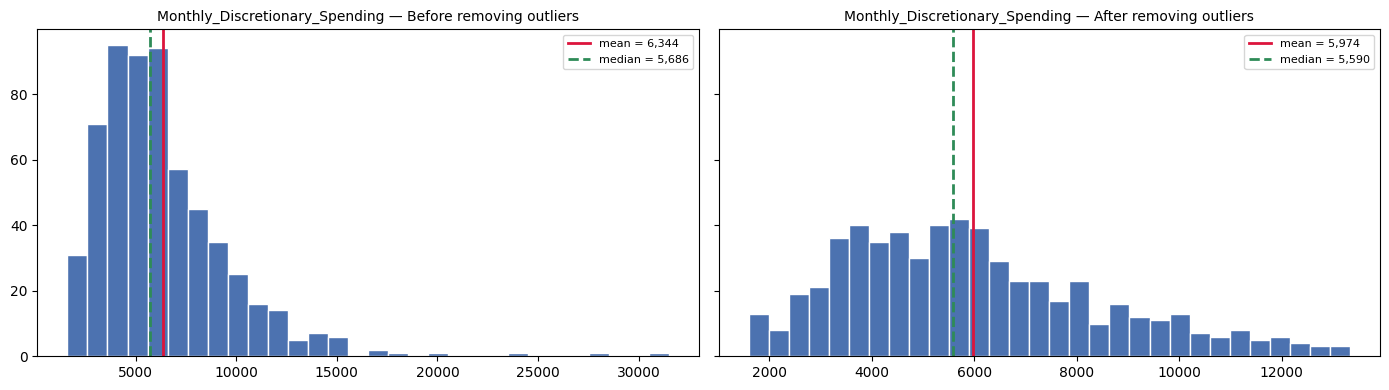

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, (data, title) in zip(axes, [(before, "Before removing outliers"),
                                    (after,  "After removing outliers")]):
    ax.hist(data, bins=30, color="#4C72B0", edgecolor="white")
    ax.axvline(data.mean(),   color="crimson",  lw=2, label=f"mean = {data.mean():,.0f}")
    ax.axvline(data.median(), color="seagreen", lw=2, ls="--", label=f"median = {data.median():,.0f}")
    ax.set_title(f"{FOCUS} — {title}", fontsize=10)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [53]:
N = len(df)

A = df["Part_Time_Job"] == "Yes"
B = df["Stress_Score"] >= 7
C = df["Scholarship"] == "Yes"
D = df["Exercise_Days_Per_Week"] >= 3

def P(mask):
    """Classical probability = favourable outcomes / total outcomes."""
    return mask.sum() / N

events = {"A: Part-time job": A, "B: Stress >= 7": B,
          "C: Scholarship": C, "D: Exercise >= 3 days/wk": D}

base = pd.DataFrame({
    "Count": [int(m.sum()) for m in events.values()],
    "Total": N,
    "Probability": [P(m) for m in events.values()],
}, index=events.keys())
base["Percent"] = base["Probability"] * 100
base

,Count,Total,Probability,Percent
A: Part-time job,152,600,0.253333,25.333333
B: Stress >= 7,45,600,0.075000,7.500000
C: Scholarship,184,600,0.306667,30.666667
D: Exercise >= 3 days/wk,356,600,0.593333,59.333333


In [54]:
P_A, P_B, P_C, P_D = P(A), P(B), P(C), P(D)
P_A_and_B = P(A & B)
P_A_or_B  = P(A | B)
P_A_given_B = P(A & B) / P_B
P_B_given_A = P(A & B) / P_A

print("BASIC PROBABILITIES")
print(f"  P(A) = {A.sum():>3}/{N} = {P_A:.4f}  ({P_A*100:.2f}%)")
print(f"  P(B) = {B.sum():>3}/{N} = {P_B:.4f}  ({P_B*100:.2f}%)")
print(f"  P(C) = {C.sum():>3}/{N} = {P_C:.4f}  ({P_C*100:.2f}%)")
print(f"  P(D) = {D.sum():>3}/{N} = {P_D:.4f}  ({P_D*100:.2f}%)")

print("\nCOMPOUND PROBABILITIES")
print(f"  P(A and B) = {int((A & B).sum()):>3}/{N} = {P_A_and_B:.4f}  ({P_A_and_B*100:.2f}%)")
print(f"  P(A or  B) = {int((A | B).sum()):>3}/{N} = {P_A_or_B:.4f}  ({P_A_or_B*100:.2f}%)")
print(f"  Addition-rule check: P(A)+P(B)-P(A and B) = {P_A + P_B - P_A_and_B:.4f}  "
      f"-> match: {np.isclose(P_A_or_B, P_A + P_B - P_A_and_B)}")

print("\nCONDITIONAL PROBABILITIES")
print(f"  P(A|B) = P(A and B)/P(B) = {P_A_and_B:.4f}/{P_B:.4f} = {P_A_given_B:.4f}  ({P_A_given_B*100:.2f}%)")
print(f"  P(B|A) = P(A and B)/P(A) = {P_A_and_B:.4f}/{P_A:.4f} = {P_B_given_A:.4f}  ({P_B_given_A*100:.2f}%)")

BASIC PROBABILITIES
  P(A) = 152/600 = 0.2533  (25.33%)
  P(B) =  45/600 = 0.0750  (7.50%)
  P(C) = 184/600 = 0.3067  (30.67%)
  P(D) = 356/600 = 0.5933  (59.33%)

COMPOUND PROBABILITIES
  P(A and B) =  31/600 = 0.0517  (5.17%)
  P(A or  B) = 166/600 = 0.2767  (27.67%)
  Addition-rule check: P(A)+P(B)-P(A and B) = 0.2767  -> match: True

CONDITIONAL PROBABILITIES
  P(A|B) = P(A and B)/P(B) = 0.0517/0.0750 = 0.6889  (68.89%)
  P(B|A) = P(A and B)/P(A) = 0.0517/0.2533 = 0.2039  (20.39%)


In [55]:
ct = pd.crosstab(df["Part_Time_Job"], B.map({True: "Stress >= 7", False: "Stress < 7"}),
                 rownames=["Part-time job"], colnames=["Stress group"],
                 margins=True, margins_name="Total")
print("COUNTS"); print(ct)
print("\nJOINT PROBABILITIES"); print((ct / N).round(4))

COUNTS
Stress group   Stress < 7  Stress >= 7  Total
Part-time job                                
No                    434           14    448
Yes                   121           31    152
Total                 555           45    600

JOINT PROBABILITIES
Stress group   Stress < 7  Stress >= 7   Total
Part-time job                                 
No                 0.7233       0.0233  0.7467
Yes                0.2017       0.0517  0.2533
Total              0.9250       0.0750  1.0000


In [56]:
Y1 = df["Year_of_Study"] == 1
Y4 = df["Year_of_Study"] == 4

P_Y1, P_Y4 = P(Y1), P(Y4)
P_Y1_and_Y4 = P(Y1 & Y4)
P_Y1_or_Y4  = P(Y1 | Y4)

print(f"P(Year = 1)            = {P_Y1:.4f}   ({int(Y1.sum())} students)")
print(f"P(Year = 4)            = {P_Y4:.4f}   ({int(Y4.sum())} students)")
print(f"P(Year = 1 AND Year=4) = {P_Y1_and_Y4:.4f}   ({int((Y1 & Y4).sum())} students)")
print(f"P(Year = 1 OR  Year=4) = {P_Y1_or_Y4:.4f}")
print(f"P(Y1) + P(Y4)          = {P_Y1 + P_Y4:.4f}")

mutually_exclusive = P_Y1_and_Y4 == 0
print(f"\nMutually exclusive? {mutually_exclusive}")
print(f"Simple addition rule P(Y1 or Y4) = P(Y1) + P(Y4) holds: "
      f"{np.isclose(P_Y1_or_Y4, P_Y1 + P_Y4)}")

print(f"\nExhaustive? P(Y1 or Y4) = {P_Y1_or_Y4:.4f} != 1 -> NO "
      f"(years 2 and 3 cover the remaining {(1 - P_Y1_or_Y4)*100:.2f}%)")

P(Year = 1)            = 0.2733   (164 students)
P(Year = 4)            = 0.2000   (120 students)
P(Year = 1 AND Year=4) = 0.0000   (0 students)
P(Year = 1 OR  Year=4) = 0.4733
P(Y1) + P(Y4)          = 0.4733

Mutually exclusive? True
Simple addition rule P(Y1 or Y4) = P(Y1) + P(Y4) holds: True

Exhaustive? P(Y1 or Y4) = 0.4733 != 1 -> NO (years 2 and 3 cover the remaining 52.67%)


In [57]:
product = P_A * P_B
diff  = P_A_and_B - product
ratio = P_A_and_B / product

print("INDEPENDENCE CHECK")
print(f"  P(A and B) observed = {P_A_and_B:.6f}")
print(f"  P(A) x P(B)         = {P_A:.6f} x {P_B:.6f} = {product:.6f}")
print(f"  Difference          = {diff:+.6f}")
print(f"  Ratio (lift)        = {ratio:.4f}")
print()
print(f"  P(A|B) = {P_A_given_B:.4f}   vs   P(A) = {P_A:.4f}   "
      f"(difference {P_A_given_B - P_A:+.4f})")
print(f"  P(B|A) = {P_B_given_A:.4f}   vs   P(B) = {P_B:.4f}   "
      f"(difference {P_B_given_A - P_B:+.4f})")

print(f"\n  Observed A and B students : {int((A & B).sum())}")
print(f"  Expected under independence: {product * N:.2f}")

INDEPENDENCE CHECK
  P(A and B) observed = 0.051667
  P(A) x P(B)         = 0.253333 x 0.075000 = 0.019000
  Difference          = +0.032667
  Ratio (lift)        = 2.7193

  P(A|B) = 0.6889   vs   P(A) = 0.2533   (difference +0.4356)
  P(B|A) = 0.2039   vs   P(B) = 0.0750   (difference +0.1289)

  Observed A and B students : 31
  Expected under independence: 11.40


In [58]:
obs = pd.crosstab(A, B).values
chi2, pval, dof, expected = stats.chi2_contingency(obs, correction=False)

print("CHI-SQUARE TEST OF INDEPENDENCE")
print("Observed:\n", obs)
print("Expected:\n", np.round(expected, 2))
print(f"\nchi2 = {chi2:.4f}   dof = {dof}   p-value = {pval:.4f}")
print("Decision at alpha = 0.05:",
      "REJECT independence" if pval < 0.05 else "FAIL TO REJECT independence")

CHI-SQUARE TEST OF INDEPENDENCE
Observed:
 [[434  14]
 [121  31]]
Expected:
 [[414.4  33.6]
 [140.6  11.4]]

chi2 = 48.7909   dof = 1   p-value = 0.0000
Decision at alpha = 0.05: REJECT independence


In [60]:
not_A = ~A

P_notA      = P(not_A)
P_B_given_notA = P(B & not_A) / P_notA

print("BAYES INPUTS")
print(f"  P(A)      = {P_A:.6f}      (prior: student has a part-time job)")
print(f"  P(not A)  = {P_notA:.6f}")
print(f"  P(B|A)    = {P_B_given_A:.6f}      (likelihood)")
print(f"  P(B|not A)= {P_B_given_notA:.6f}")

P_B_total = P_B_given_A * P_A + P_B_given_notA * P_notA
print(f"\nLAW OF TOTAL PROBABILITY")
print(f"  P(B) = P(B|A)P(A) + P(B|not A)P(not A)")
print(f"       = {P_B_given_A:.6f} x {P_A:.6f} + {P_B_given_notA:.6f} x {P_notA:.6f}")
print(f"       = {P_B_total:.6f}")
print(f"  Direct P(B) = {P_B:.6f}   -> match: {np.isclose(P_B_total, P_B)}")

P_A_given_B_bayes = (P_B_given_A * P_A) / P_B_total
print(f"\nBAYES' THEOREM")
print(f"  P(A|B) = P(B|A)P(A) / P(B)")
print(f"         = ({P_B_given_A:.6f} x {P_A:.6f}) / {P_B_total:.6f}")
print(f"         = {P_A_given_B_bayes:.6f}")

BAYES INPUTS
  P(A)      = 0.253333      (prior: student has a part-time job)
  P(not A)  = 0.746667
  P(B|A)    = 0.203947      (likelihood)
  P(B|not A)= 0.031250

LAW OF TOTAL PROBABILITY
  P(B) = P(B|A)P(A) + P(B|not A)P(not A)
       = 0.203947 x 0.253333 + 0.031250 x 0.746667
       = 0.075000
  Direct P(B) = 0.075000   -> match: True

BAYES' THEOREM
  P(A|B) = P(B|A)P(A) / P(B)
         = (0.203947 x 0.253333) / 0.075000
         = 0.688889


In [61]:
print("VERIFICATION — Bayes vs direct calculation")
print(f"  Bayes'  P(A|B) = {P_A_given_B_bayes:.10f}")
print(f"  Direct  P(A|B) = {P_A_given_B:.10f}")
print(f"  Absolute difference = {abs(P_A_given_B_bayes - P_A_given_B):.2e}")
print(f"  Agree (np.isclose)  = {np.isclose(P_A_given_B_bayes, P_A_given_B)}")

assert np.isclose(P_A_given_B_bayes, P_A_given_B), "Bayes result does not match the direct calculation!"
print("\nAssertion passed — the two routes give the same answer.")

print(f"\nPrior  P(A)   = {P_A:.4f}")
print(f"Posterior P(A|B) = {P_A_given_B_bayes:.4f}")
print(f"Belief updated by {(P_A_given_B_bayes - P_A)*100:+.2f} percentage points after learning the student is highly stressed.")

VERIFICATION — Bayes vs direct calculation
  Bayes'  P(A|B) = 0.6888888889
  Direct  P(A|B) = 0.6888888889
  Absolute difference = 0.00e+00
  Agree (np.isclose)  = True

Assertion passed — the two routes give the same answer.

Prior  P(A)   = 0.2533
Posterior P(A|B) = 0.6889
Belief updated by +43.56 percentage points after learning the student is highly stressed.


In [62]:
ars = df["Academic_Readiness_Score"]

mu       = ars.mean()
sigma_s  = ars.std(ddof=1)
sigma_p  = ars.std(ddof=0)

print("ACADEMIC READINESS SCORE")
print(f"  n                       = {ars.size}")
print(f"  Mean (mu)               = {mu:.4f}")
print(f"  Sample std dev (n-1)    = {sigma_s:.4f}")
print(f"  Population std dev (n)  = {sigma_p:.4f}")
print(f"  Median                  = {ars.median():.4f}")
print(f"  Skewness                = {ars.skew():.4f}")
print(f"  Kurtosis (excess)       = {ars.kurtosis():.4f}")
print(f"  Min / Max               = {ars.min():.2f} / {ars.max():.2f}")

ACADEMIC READINESS SCORE
  n                       = 600
  Mean (mu)               = 71.7732
  Sample std dev (n-1)    = 9.6944
  Population std dev (n)  = 9.6863
  Median                  = 71.6500
  Skewness                = -0.1295
  Kurtosis (excess)       = -0.0039
  Min / Max               = 41.90 / 98.00


In [63]:
hi_idx, lo_idx = ars.idxmax(), ars.idxmin()
x_hi, x_lo = ars[hi_idx], ars[lo_idx]

z_hi = (x_hi - mu) / sigma_s
z_lo = (x_lo - mu) / sigma_s

print("HIGHEST SCORER")
print(f"  Student_ID = {df.loc[hi_idx, 'Student_ID']}   Faculty = {df.loc[hi_idx, 'Faculty']}   Year = {df.loc[hi_idx, 'Year_of_Study']}")
print(f"  Score x    = {x_hi:.2f}")
print(f"  Z = (x - mu)/sigma = ({x_hi:.2f} - {mu:.4f}) / {sigma_s:.4f} = {z_hi:+.4f}")
print(f"  Percentile under the normal model = {stats.norm.cdf(z_hi)*100:.2f}%")
print(f"  Actual percentile in the data     = {(ars <= x_hi).mean()*100:.2f}%")

print("\nLOWEST SCORER")
print(f"  Student_ID = {df.loc[lo_idx, 'Student_ID']}   Faculty = {df.loc[lo_idx, 'Faculty']}   Year = {df.loc[lo_idx, 'Year_of_Study']}")
print(f"  Score x    = {x_lo:.2f}")
print(f"  Z = ({x_lo:.2f} - {mu:.4f}) / {sigma_s:.4f} = {z_lo:+.4f}")
print(f"  Percentile under the normal model = {stats.norm.cdf(z_lo)*100:.2f}%")
print(f"  Actual percentile in the data     = {(ars <= x_lo).mean()*100:.2f}%")

HIGHEST SCORER
  Student_ID = STU0131   Faculty = Business   Year = 4
  Score x    = 98.00
  Z = (x - mu)/sigma = (98.00 - 71.7732) / 9.6944 = +2.7054
  Percentile under the normal model = 99.66%
  Actual percentile in the data     = 100.00%

LOWEST SCORER
  Student_ID = STU0543   Faculty = Arts & Humanities   Year = 3
  Score x    = 41.90
  Z = (41.90 - 71.7732) / 9.6944 = -3.0815
  Percentile under the normal model = 0.10%
  Actual percentile in the data     = 0.17%


In [64]:
def interpret_z(z):
    d, side = abs(z), "above" if z > 0 else "below"
    if d < 1:   band = "within 1 SD — typical, unremarkable"
    elif d < 2: band = "between 1 and 2 SD — somewhat unusual"
    elif d < 3: band = "between 2 and 3 SD — rare (outer ~5% of a normal curve)"
    else:       band = "beyond 3 SD — extreme (outer ~0.3% of a normal curve)"
    return f"{d:.2f} standard deviations {side} the mean; {band}"

print("Z-SCORE INTERPRETATION")
print(f"  Highest scorer (Z = {z_hi:+.4f}): {interpret_z(z_hi)}")
print(f"     -> scores better than about {stats.norm.cdf(z_hi)*100:.1f}% of a normally distributed cohort.")
print(f"  Lowest scorer  (Z = {z_lo:+.4f}): {interpret_z(z_lo)}")
print(f"     -> scores better than only about {stats.norm.cdf(z_lo)*100:.1f}% of a normally distributed cohort.")
print(f"\n  Total spread from lowest to highest = {z_hi - z_lo:.2f} standard deviations.")

Z-SCORE INTERPRETATION
  Highest scorer (Z = +2.7054): 2.71 standard deviations above the mean; between 2 and 3 SD — rare (outer ~5% of a normal curve)
     -> scores better than about 99.7% of a normally distributed cohort.
  Lowest scorer  (Z = -3.0815): 3.08 standard deviations below the mean; beyond 3 SD — extreme (outer ~0.3% of a normal curve)
     -> scores better than only about 0.1% of a normally distributed cohort.

  Total spread from lowest to highest = 5.79 standard deviations.


In [65]:
expected = {1: 68.27, 2: 95.45, 3: 99.73}
rows = []
for k in (1, 2, 3):
    lo_b, hi_b = mu - k * sigma_s, mu + k * sigma_s
    inside = ((ars >= lo_b) & (ars <= hi_b))
    rows.append({
        "Interval": f"mu ± {k} sigma",
        "Lower": lo_b, "Upper": hi_b,
        "Expected %": expected[k],
        "Expected students": expected[k] / 100 * len(ars),
        "Observed count": int(inside.sum()),
        "Observed %": inside.mean() * 100,
        "Difference (pp)": inside.mean() * 100 - expected[k],
    })

emp = pd.DataFrame(rows).set_index("Interval")
emp

,Lower,Upper,Expected %,Expected students,Observed count,Observed %,Difference (pp)
Interval,,,,,,,
mu ± 1 sigma,62.078737,81.467596,68.27,409.62,417,69.500000,1.230000
mu ± 2 sigma,52.384307,91.162026,95.45,572.70,571,95.166667,-0.283333
mu ± 3 sigma,42.689878,100.856456,99.73,598.38,599,99.833333,0.103333


In [68]:
print("EMPIRICAL RULE — EXPECTED PERCENTAGE OF STUDENTS")
for k in (1, 2, 3):
    r = emp.loc[f"mu ± {k} sigma"]
    print(f"  Within {k} SD  [{r['Lower']:6.2f}, {r['Upper']:6.2f}] : "
          f"expected {r['Expected %']:5.2f}%  (~{r['Expected students']:.0f} students)   "
          f"observed {r['Observed %']:5.2f}%  ({int(r['Observed count'])} students)   "
          f"diff {r['Difference (pp)']:+.2f} pp")

sh_stat, sh_p = stats.shapiro(ars)
ks_stat, ks_p = stats.kstest(ars, "norm", args=(mu, sigma_s))
print(f"\nShapiro-Wilk : W = {sh_stat:.4f}, p = {sh_p:.4f}")
print(f"K-S test     : D = {ks_stat:.4f}, p = {ks_p:.4f}")
print("At alpha = 0.05 ->",
      "normality NOT rejected" if sh_p > 0.05 else "normality rejected (but see the plots)")

EMPIRICAL RULE — EXPECTED PERCENTAGE OF STUDENTS
  Within 1 SD  [ 62.08,  81.47] : expected 68.27%  (~410 students)   observed 69.50%  (417 students)   diff +1.23 pp
  Within 2 SD  [ 52.38,  91.16] : expected 95.45%  (~573 students)   observed 95.17%  (571 students)   diff -0.28 pp
  Within 3 SD  [ 42.69, 100.86] : expected 99.73%  (~598 students)   observed 99.83%  (599 students)   diff +0.10 pp

Shapiro-Wilk : W = 0.9970, p = 0.3500
K-S test     : D = 0.0222, p = 0.9221
At alpha = 0.05 -> normality NOT rejected


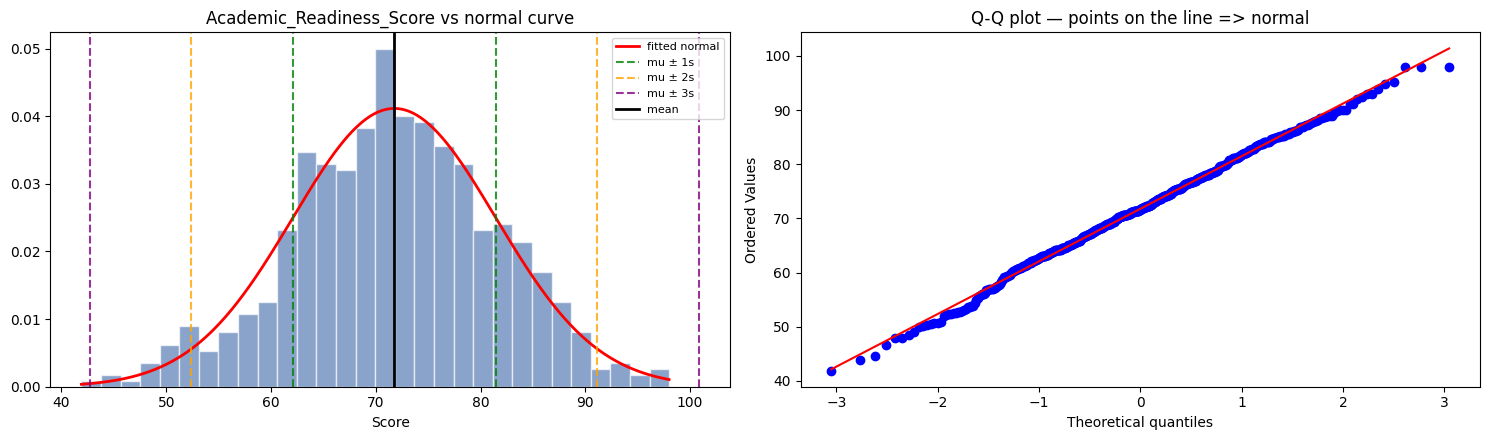

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

ax = axes[0]
ax.hist(ars, bins=30, density=True, color="#4C72B0", alpha=0.65, edgecolor="white")
xs = np.linspace(ars.min(), ars.max(), 400)
ax.plot(xs, stats.norm.pdf(xs, mu, sigma_s), "r-", lw=2, label="fitted normal")
for k, c in zip((1, 2, 3), ("green", "orange", "purple")):
    ax.axvline(mu - k * sigma_s, color=c, ls="--", alpha=0.8)
    ax.axvline(mu + k * sigma_s, color=c, ls="--", alpha=0.8, label=f"mu ± {k}s")
ax.axvline(mu, color="black", lw=2, label="mean")
ax.set_title("Academic_Readiness_Score vs normal curve")
ax.set_xlabel("Score"); ax.legend(fontsize=8)

stats.probplot(ars, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot — points on the line => normal")
plt.tight_layout()
plt.show()

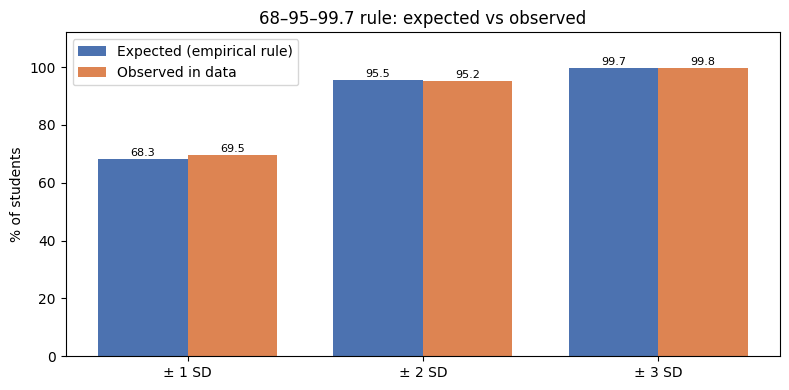

In [70]:
fig, ax = plt.subplots(figsize=(8, 4))
idx = np.arange(3); w = 0.38
ax.bar(idx - w/2, emp["Expected %"], w, label="Expected (empirical rule)", color="#4C72B0")
ax.bar(idx + w/2, emp["Observed %"], w, label="Observed in data", color="#DD8452")
for i in idx:
    ax.text(i - w/2, emp["Expected %"].iloc[i] + 1, f"{emp['Expected %'].iloc[i]:.1f}", ha="center", fontsize=8)
    ax.text(i + w/2, emp["Observed %"].iloc[i] + 1, f"{emp['Observed %'].iloc[i]:.1f}", ha="center", fontsize=8)
ax.set_xticks(idx); ax.set_xticklabels(["± 1 SD", "± 2 SD", "± 3 SD"])
ax.set_ylabel("% of students"); ax.set_ylim(0, 112)
ax.set_title("68–95–99.7 rule: expected vs observed")
ax.legend()
plt.tight_layout(); plt.show()